In [11]:
import kagglehub
import pandas as pd
import numpy as np
import os

path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
print(" Path to dataset files:", path)

files = [
'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
'Monday-WorkingHours.pcap_ISCX.csv',
'Friday-WorkingHours-Morning.pcap_ISCX.csv',
'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
'Tuesday-WorkingHours.pcap_ISCX.csv',
'Wednesday-workingHours.pcap_ISCX.csv',
'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
       
       ]

dfs = []

for file in files:
    df = pd.read_csv(os.path.join(path, file))
    df.columns = df.columns.str.strip()
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(data.shape)
print(data['Label'].value_counts())

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1
(2830743, 79)
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

X = data.drop('Label', axis=1)
y = data['Label']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

from  xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

'''for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] 

    xgb = XGBClassifier(eval_metric='mlogloss', random_state=1)
    xgb.fit(X_train, y_train)


    y_pred = xgb.predict(X_test)
    print('-Fold--')
    print(classification_report(y_test, y_pred))'''

"for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):\n    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]\n    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] \n\n    xgb = XGBClassifier(eval_metric='mlogloss', random_state=1)\n    xgb.fit(X_train, y_train)\n\n\n    y_pred = xgb.predict(X_test)\n    print('-Fold--')\n    print(classification_report(y_test, y_pred))"

15
1.0
[8.3889170e-03 3.1720111e-04 2.9140683e-02 1.8554829e-02 2.0554787e-02
 1.3146893e-02 1.8097168e-02 1.2072077e-02 2.1844255e-03 3.3161591e-03
 2.8895674e-04 1.0983845e-03 6.0164094e-02 1.2504217e-01 7.2899703e-03
 4.6814288e-04 4.6380316e-03 2.7583077e-04 1.3607263e-04 2.9761673e-04
 3.1807326e-04 1.4583262e-04 1.0795890e-04 5.7242753e-04 5.9633696e-04
 1.2818599e-04 2.8423446e-03 6.5180636e-04 7.2571158e-04 3.4716932e-04
 2.0899668e-03 0.0000000e+00 0.0000000e+00 0.0000000e+00 4.0494660e-03
 6.9859542e-02 2.1478297e-04 1.5915999e-02 1.7181780e-03 3.2363560e-02
 2.0834729e-03 8.4266264e-04 6.9620760e-06 1.3550288e-02 0.0000000e+00
 0.0000000e+00 9.5438898e-02 1.7926995e-04 9.6214600e-05 0.0000000e+00
 0.0000000e+00 5.6838250e-04 7.4459985e-02 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 8.5939880e-04 3.7497869e-03 8.2011484e-02 5.4968176e-03

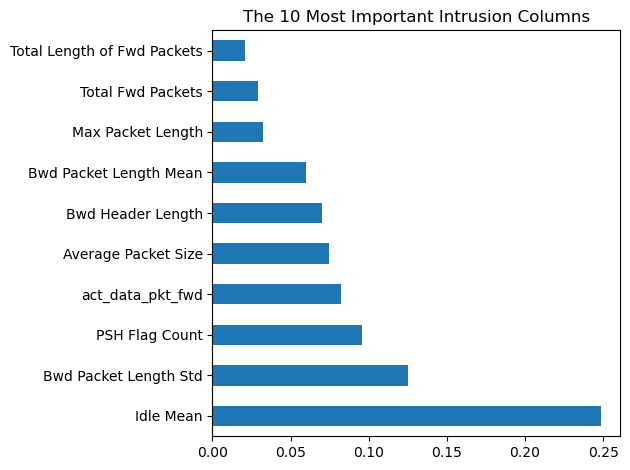

In [14]:
import matplotlib.pyplot as plt

xgb_importance = XGBClassifier(eval_metric='mlogloss', random_state=1)
xgb_importance.fit(X,y)


print(xgb_importance.n_classes_)
print(xgb_importance.feature_importances_.sum())
print(xgb_importance.feature_importances_)

importance = pd.Series(xgb_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features - XGBoost')
plt.tight_layout()
plt.show()